In [105]:
#making changes restoring invoice date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans,DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo,list_available_datasets
from collections import defaultdict
from pprint import pprint
import plotly.express as px

In [2]:
online_retail=fetch_ucirepo(id=352)

In [3]:
online_retail

{'data': {'ids':        InvoiceNo StockCode
  0         536365    85123A
  1         536365     71053
  2         536365    84406B
  3         536365    84029G
  4         536365    84029E
  ...          ...       ...
  541904    581587     22613
  541905    581587     22899
  541906    581587     23254
  541907    581587     23255
  541908    581587     22138
  
  [541909 rows x 2 columns],
  'features':                                 Description  Quantity      InvoiceDate  \
  0        WHITE HANGING HEART T-LIGHT HOLDER         6   12/1/2010 8:26   
  1                       WHITE METAL LANTERN         6   12/1/2010 8:26   
  2            CREAM CUPID HEARTS COAT HANGER         8   12/1/2010 8:26   
  3       KNITTED UNION FLAG HOT WATER BOTTLE         6   12/1/2010 8:26   
  4            RED WOOLLY HOTTIE WHITE HEART.         6   12/1/2010 8:26   
  ...                                     ...       ...              ...   
  541904          PACK OF 20 SPACEBOY NAPKINS        12  12/9

In [4]:
online_retail=online_retail.data.original
online_retail.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Explorartion

In [114]:
online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   InvoiceNo                541909 non-null  object        
 1   StockCode                541909 non-null  object        
 2   Quantity                 541909 non-null  int64         
 3   InvoiceDate              541909 non-null  datetime64[ns]
 4   UnitPrice                541909 non-null  float64       
 5   CustomerID               541909 non-null  object        
 6   InvoiceDate_year         541909 non-null  int32         
 7   InvoiceDate_month        541909 non-null  int32         
 8   InvoiceDate_day          541909 non-null  int32         
 9   InvoiceDate_hr           541909 non-null  int32         
 10  InvoiceDate_day_of_week  541909 non-null  int32         
 11  Week                     541909 non-null  object        
 12  Total Amount    

In [116]:
# let us see the statistics of data
online_retail.describe()

,Quantity,InvoiceDate,UnitPrice,InvoiceDate_year,InvoiceDate_month,InvoiceDate_day,InvoiceDate_hr,InvoiceDate_day_of_week,Total Amount
count,541909.000000,541909,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,2010.921609,7.553128,15.023096,13.078729,2.431277,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,2010.000000,1.000000,1.000000,6.000000,0.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,2011.000000,5.000000,7.000000,11.000000,1.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,2011.000000,8.000000,15.000000,13.000000,2.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,2011.000000,11.000000,22.000000,15.000000,4.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,2011.000000,12.000000,31.000000,20.000000,6.000000,168469.600000
std,218.081158,NaN,96.759853,0.268787,3.509055,8.664063,2.443270,1.844709,378.810824


In [6]:
null_vals=pd.DataFrame(online_retail.isnull().sum(),columns=['Amount of null value'])

In [7]:
null_vals

,Amount of null value
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


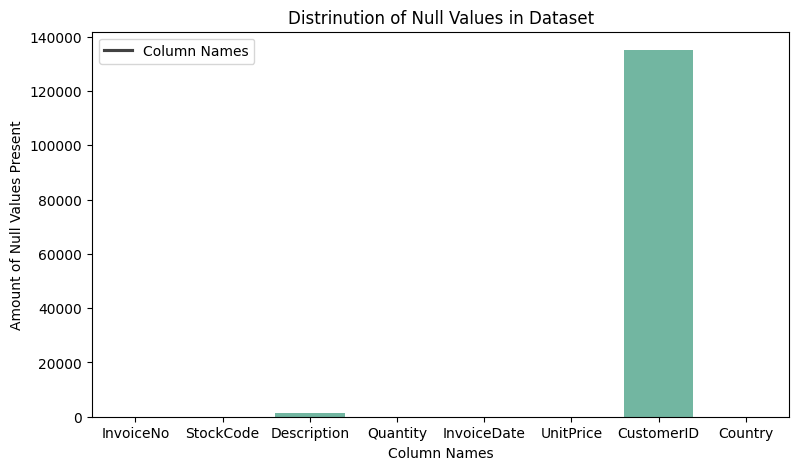

In [113]:
#plotting the columns and null values
sns.set_palette("Set2") 

plt.figure(figsize=(9,5))
sns.barplot(data=null_vals,x=null_vals.index,y='Amount of null value')
plt.xlabel('Column Names')
plt.ylabel('Amount of Null Values Present')
plt.title("Distrinution of Null Values in Dataset")
plt.legend(['Column Names'])
plt.show()

## Data cleaning,Preprocessing

In [11]:
#helper function 
def create_data_dict(df,col1,col2):
    data_dict={}
    for row in df.itertuples(index=False):
        key=getattr(row, col1)
        val=getattr(row,col2)
        if key not in data_dict:
            data_dict[key]=[val]
        else:
            if pd.notna(val) and  val not in data_dict[key]:
                data_dict[key].append(val)

    return data_dict


#

In [12]:
online_retail['CustomerID']=online_retail['CustomerID'].astype('str')

In this section we will perform data cleaning, fill out missing values and do some data processing.

Since the dataset contains more UK based customers, we will drop the country column for now

In [13]:
country=online_retail['Country']
online_retail.drop(columns=['Country'],inplace=True)

Create a dictionary with stockcodes and their description</br>
This will help in filling out any missing values

In [14]:
#will give dictionary of stock codes with their corresponding prices
desc_dict=create_data_dict(online_retail,'StockCode','Description')
desc_dict

{'85123A': ['WHITE HANGING HEART T-LIGHT HOLDER',
  '?',
  'wrongly marked carton 22804',
  'CREAM HANGING HEART T-LIGHT HOLDER'],
 '71053': ['WHITE METAL LANTERN', 'WHITE MOROCCAN METAL LANTERN'],
 '84406B': ['CREAM CUPID HEARTS COAT HANGER',
  'incorrectly made-thrown away.',
  '?'],
 '84029G': ['KNITTED UNION FLAG HOT WATER BOTTLE'],
 '84029E': ['RED WOOLLY HOTTIE WHITE HEART.'],
 '22752': ['SET 7 BABUSHKA NESTING BOXES'],
 '21730': ['GLASS STAR FROSTED T-LIGHT HOLDER'],
 '22633': ['HAND WARMER UNION JACK'],
 '22632': ['HAND WARMER RED POLKA DOT', 'HAND WARMER RED RETROSPOT'],
 '84879': ['ASSORTED COLOUR BIRD ORNAMENT', 'damaged'],
 '22745': ["POPPY'S PLAYHOUSE BEDROOM "],
 '22748': ["POPPY'S PLAYHOUSE KITCHEN"],
 '22749': ['FELTCRAFT PRINCESS CHARLOTTE DOLL'],
 '22310': ['IVORY KNITTED MUG COSY '],
 '84969': ['BOX OF 6 ASSORTED COLOUR TEASPOONS', 'check'],
 '22623': ['BOX OF VINTAGE JIGSAW BLOCKS '],
 '22622': ['BOX OF VINTAGE ALPHABET BLOCKS'],
 '21754': ['HOME BUILDING BLOCK WORD

In [15]:
#will check if each invoice number has both null value and valid value for customer id or not
cust_id_dict=create_data_dict(online_retail,'InvoiceNo','CustomerID')
cust_id_dict

{'536365': ['17850.0'],
 '536366': ['17850.0'],
 '536367': ['13047.0'],
 '536368': ['13047.0'],
 '536369': ['13047.0'],
 '536370': ['12583.0'],
 '536371': ['13748.0'],
 '536372': ['17850.0'],
 '536373': ['17850.0'],
 '536374': ['15100.0'],
 '536375': ['17850.0'],
 '536376': ['15291.0'],
 '536377': ['17850.0'],
 '536378': ['14688.0'],
 '536380': ['17809.0'],
 '536381': ['15311.0'],
 'C536379': ['14527.0'],
 '536382': ['16098.0'],
 'C536383': ['15311.0'],
 '536384': ['18074.0'],
 '536385': ['17420.0'],
 '536386': ['16029.0'],
 '536387': ['16029.0'],
 '536388': ['16250.0'],
 '536389': ['12431.0'],
 '536390': ['17511.0'],
 'C536391': ['17548.0'],
 '536392': ['13705.0'],
 '536393': ['13747.0'],
 '536394': ['13408.0'],
 '536395': ['13767.0'],
 '536396': ['17850.0'],
 '536397': ['17924.0'],
 '536398': ['13448.0'],
 '536399': ['17850.0'],
 '536400': ['13448.0'],
 '536401': ['15862.0'],
 '536402': ['15513.0'],
 '536403': ['12791.0'],
 '536404': ['16218.0'],
 '536405': ['14045.0'],
 '536406': ['

After analysing it seems that for certain invoice numbers, customer id is not present</br>
We were hoping maybe for a certain invoice number we have both valid customer id and missing values, so missing values can be filled with valid values.</br>
So now we have do work around.</br>
We will generate synthetic customer id, for missing values</br>
Which will be 'C'+invoice_id

In [16]:
#function to fill missing values
def fill_null_values(row,values,col_to_fil,ref_col):
    if row[col_to_fil]=='nan':
        return values.get(row[ref_col],row[col_to_fil])
    else:
        return row[col_to_fil]

def generate_customer_id():
    new_cust_ids={}
    for invoice_no,cust_id in zip(online_retail['InvoiceNo'],online_retail['CustomerID']):
        if cust_id=='nan':  #after converting to str, all null vals in customer id got converted to 'nan'
            new_id='Cust'+invoice_no
            new_cust_ids[invoice_no]=new_id

    return new_cust_ids
            
        
                        
        

cust_id_dict=generate_customer_id()
online_retail['CustomerID']=online_retail.apply(lambda row: fill_null_values(row,cust_id_dict,'CustomerID','InvoiceNo'),axis=1)



In [17]:
online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 28.9+ MB


Extract the date time components and craete new features</br>
1) Extracting the day,month,year,hour,minute to identify customer behaviour and peak sales hours
2) create a weekend/weekday feature

In [18]:
online_retail['InvoiceDate']=pd.to_datetime(online_retail['InvoiceDate'])  #convert to datetime
online_retail['InvoiceDate_year']=online_retail['InvoiceDate'].dt.year  #extract year
online_retail['InvoiceDate_month']=online_retail['InvoiceDate'].dt.month #extract month
online_retail['InvoiceDate_day']=online_retail['InvoiceDate'].dt.day  #extract day
online_retail['InvoiceDate_hr']=online_retail['InvoiceDate'].dt.hour #extract hour
online_retail['InvoiceDate_day_of_week']=online_retail['InvoiceDate'].dt.dayofweek #extract day of week

online_retail['Week']=online_retail['InvoiceDate_day_of_week'].apply(lambda x: 'Weekend' if x>5 else "Weekday")




In [19]:
#drop invoice date column and description column
online_retail.drop(columns=['Description'],inplace=True)


Adding two extra features
1) Total Amount
2) And whether it was return or purchase

In [20]:
online_retail['Total Amount']=online_retail['UnitPrice']*online_retail['Quantity']

In [21]:
#if total amount is less than 0 that is a return
online_retail['PurchaseType']=online_retail['Total Amount'].apply(lambda x: 'Return' if x<0 else 'Purchase') 

In [22]:
online_retail.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceDate_year,InvoiceDate_month,InvoiceDate_day,InvoiceDate_hr,InvoiceDate_day_of_week,Week,Total Amount,PurchaseType
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,2010,12,1,8,2,Weekday,15.30,Purchase
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,2010,12,1,8,2,Weekday,20.34,Purchase
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,2010,12,1,8,2,Weekday,22.00,Purchase
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,2010,12,1,8,2,Weekday,20.34,Purchase
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,2010,12,1,8,2,Weekday,20.34,Purchase


## Data Analysis and Visualisations

### Customer Purchase behaviour analysis


In [23]:
#let's see purchase behaviuors for customers
#let's see top 10 customers




#craete a df with customer ids and their amount spent
customer_transactions=(online_retail.groupby(by=['CustomerID']).agg({'Total Amount':'sum',
                                                                    "InvoiceNo":'count'})).reset_index()

customer_transactions.rename(columns={"InvoiceNo":"Purchases Made"},inplace=True)

#let's get total revenue 
total_revenue=customer_transactions['Total Amount'].sum()

customer_transactions['Revenue Share']=customer_transactions['Total Amount']/total_revenue
customer_transactions['Cumulative Share'] = customer_transactions['Revenue Share'].cumsum()
                                                                    


In [24]:
customer_transactions.head()

,CustomerID,Total Amount,Purchases Made,Revenue Share,Cumulative Share
0,12346.0,0.00,2,0.000000,0.000000
1,12347.0,4310.00,182,0.000442,0.000442
2,12348.0,1797.24,31,0.000184,0.000627
3,12349.0,1757.55,73,0.000180,0.000807
4,12350.0,334.40,17,0.000034,0.000841


Let us see the most valuable customers and least valuable customers in terms of their spendings

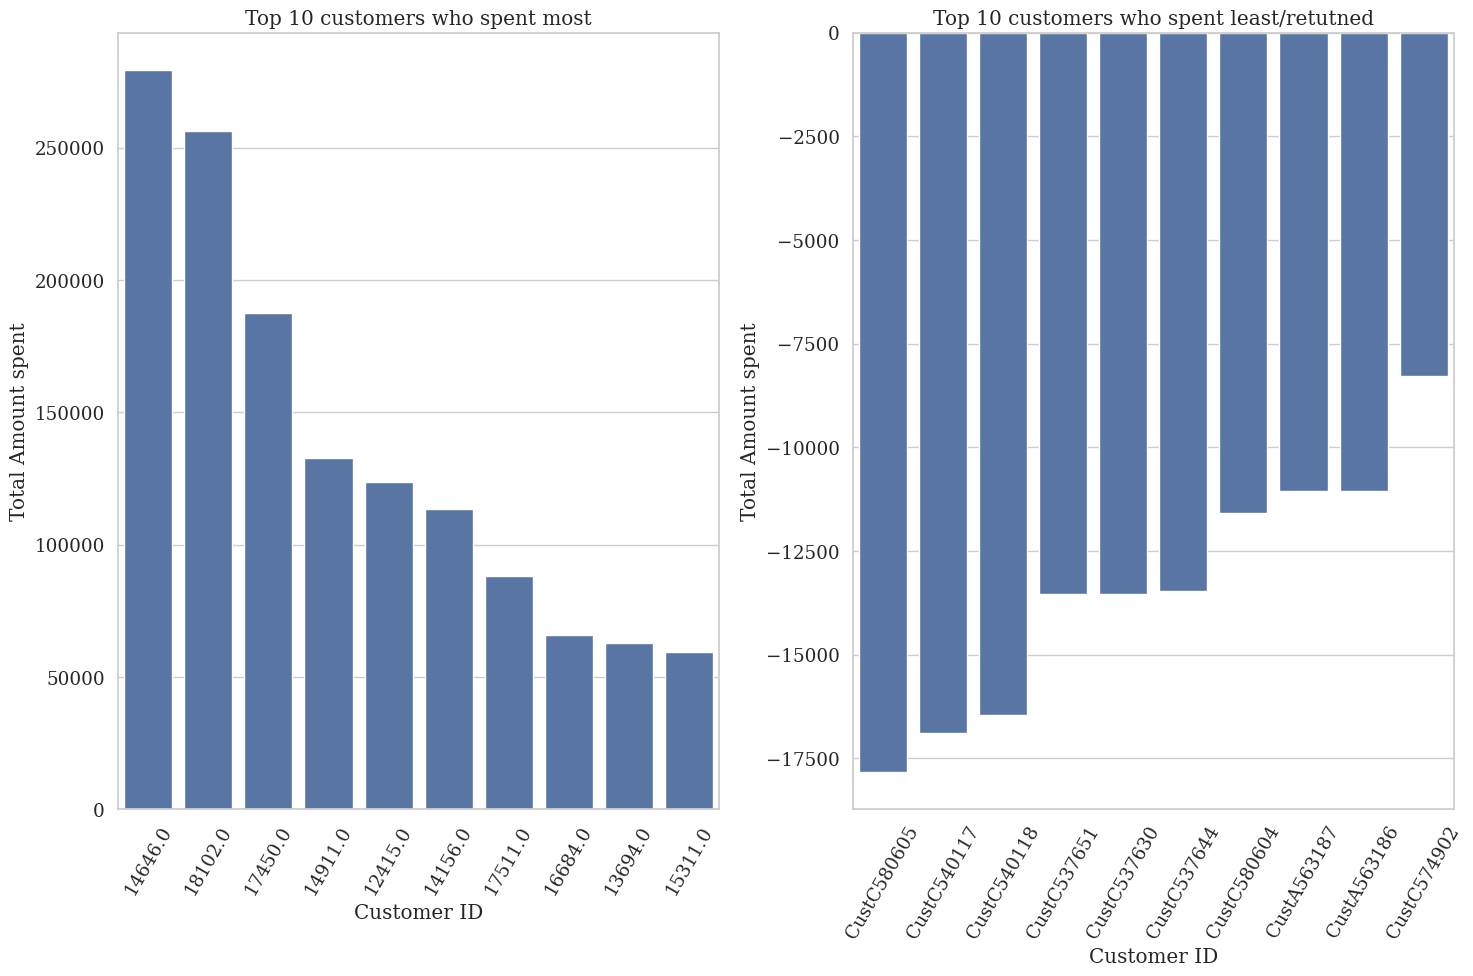

In [123]:

sns.set_theme(style="whitegrid", palette="deep", font="serif", font_scale=1.2)


fig,axes=plt.subplots(1,2,figsize=(15,10))
sns.barplot(data=customer_transactions.sort_values(by='Total Amount',ascending=False).head(10),x='CustomerID',y='Total Amount',ax=axes[0])
axes[0].set_xlabel("Customer ID")
axes[0].tick_params(axis='x',rotation=60)
axes[0].set_ylabel("Total Amount spent")
axes[0].set_title("Top 10 customers who spent most")


sns.barplot(data=customer_transactions.sort_values(by='Total Amount',ascending=True).head(10),x='CustomerID',y='Total Amount',ax=axes[1])
axes[1].set_xlabel("Customer ID")
axes[1].tick_params(axis='x',rotation=60)
axes[1].set_ylabel("Total Amount spent")
axes[1].set_title("Top 10 customers who spent least/retutned")






plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Top 10 customers with least purchases')

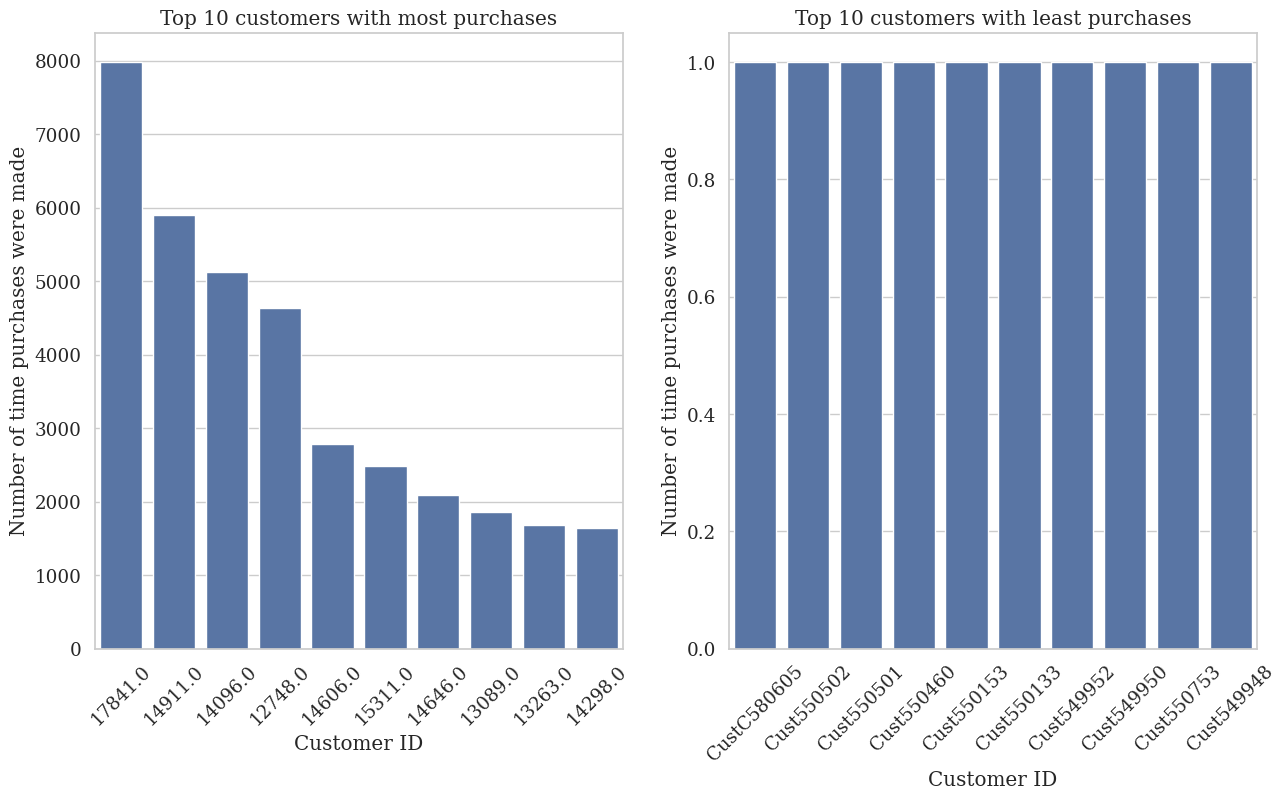

In [125]:
#most frequent and least frequent customers

sns.set_theme(style="whitegrid", palette="deep", font="serif", font_scale=1.2)

fig,axes=plt.subplots(1,2,figsize=(15,8))
sns.barplot(data=customer_transactions.sort_values(by='Purchases Made',ascending=False).head(10),x='CustomerID',y='Purchases Made',ax=axes[0])
axes[0].set_xlabel("Customer ID")
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_ylabel("Number of time purchases were made")
axes[0].set_title("Top 10 customers with most purchases")



sns.barplot(data=customer_transactions.sort_values(by='Purchases Made',ascending=True).head(10),x='CustomerID',y='Purchases Made',ax=axes[1])
axes[1].set_xlabel("Customer ID")
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_ylabel("Number of time purchases were made")
axes[1].set_title("Top 10 customers with least purchases")




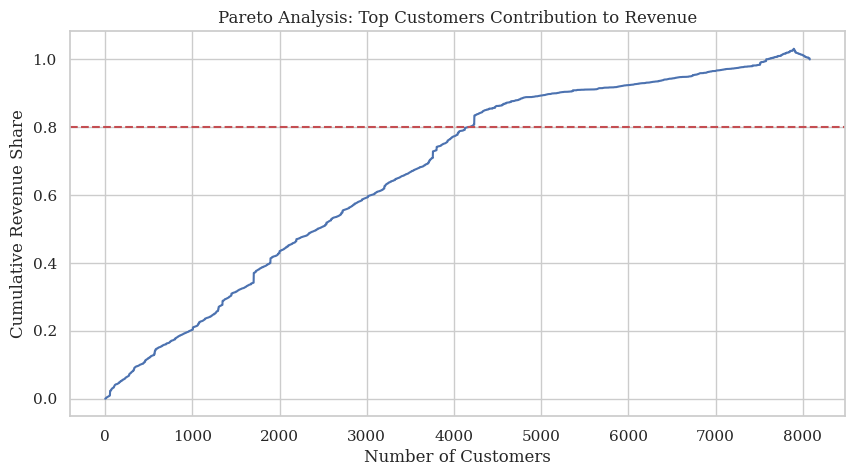

In [135]:
plt.figure(figsize=(10,5))
sns.lineplot(x=customer_transactions.index, y=customer_transactions['Cumulative Share'])
plt.axhline(y=0.8, color='r', linestyle='--')  # 80% threshold
plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Revenue Share")
plt.title("Pareto Analysis: Top Customers Contribution to Revenue")
plt.show()

### Product Demand and Analysis

In [28]:
products_summary=(online_retail.groupby(by=['StockCode']).agg({"Total Amount":"sum",
                                                               "Quantity":"sum"})).reset_index()

products_summary.head()

,StockCode,Total Amount,Quantity
0,10002,759.89,1037
1,10080,119.09,495
2,10120,40.53,193
3,10123C,3.25,-13
4,10123G,0.00,-38


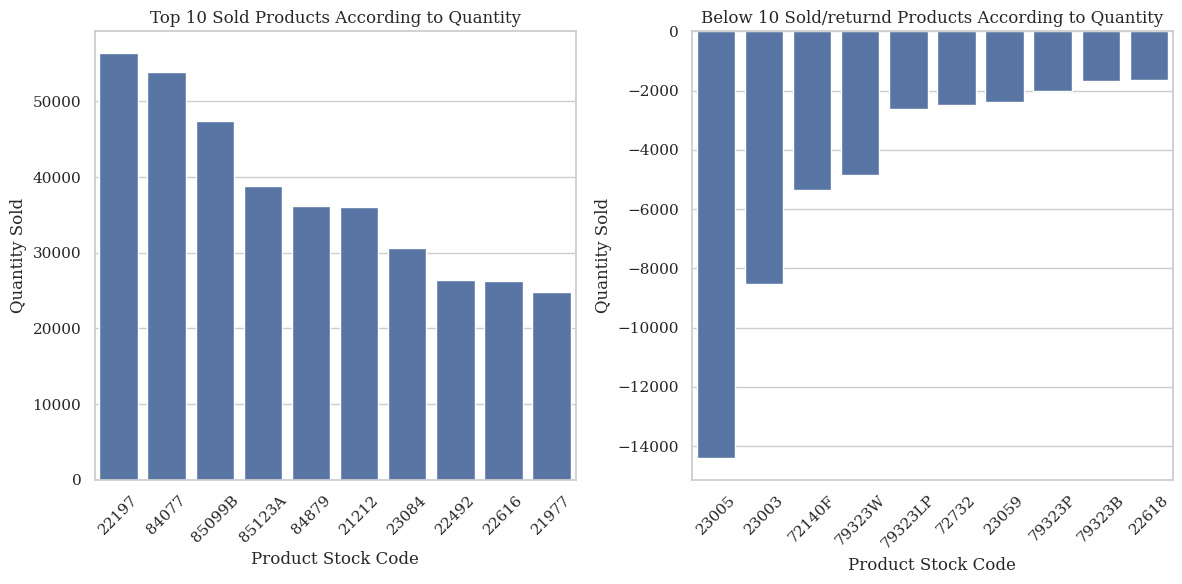

In [132]:
#looking at top 10 and worst 10 products including returns according to quantity sold

sns.set_theme(style="whitegrid", palette="deep", font="serif", font_scale=1)

fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.barplot(data=products_summary.sort_values(by='Quantity',ascending=False).head(10),x="StockCode",y='Quantity',ax=axes[0])
axes[0].set_xlabel("Product Stock Code")
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_ylabel("Quantity Sold")
axes[0].set_title("Top 10 Sold Products According to Quantity")


sns.barplot(data=products_summary.sort_values(by='Quantity',ascending=True).head(10),x="StockCode",y='Quantity',ax=axes[1])
axes[1].set_xlabel("Product Stock Code")
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_ylabel("Quantity Sold")
axes[1].set_title("Below 10 Sold/returnd Products According to Quantity")

plt.tight_layout()
plt.show()

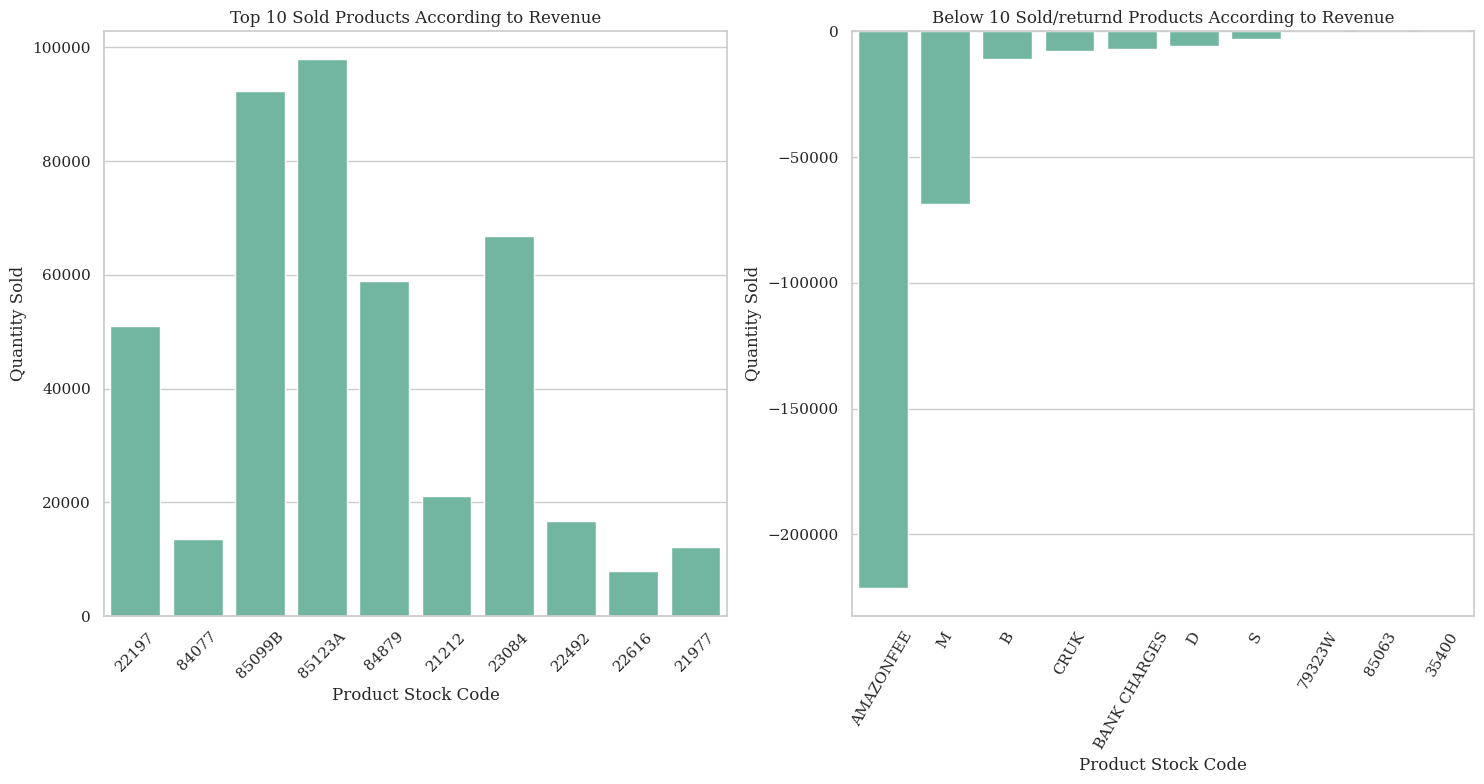

In [144]:
#looking at top 10 and worst 10 products including returns revenue generated/fefund initiated

# sns.set_theme(style="whitegrid", palette="deep", font="serif", font_scale=1)

sns.set_palette("Set2")

fig,axes=plt.subplots(1,2,figsize=(15,8.))
sns.barplot(data=products_summary.sort_values(by='Quantity',ascending=False).head(10),x="StockCode",y='Total Amount',ax=axes[0])
axes[0].set_xlabel("Product Stock Code")
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_ylabel("Quantity Sold")
axes[0].set_title("Top 10 Sold Products According to Revenue")


sns.barplot(data=products_summary.sort_values(by='Total Amount',ascending=True).head(10),x="StockCode",y='Total Amount',ax=axes[1])
axes[1].set_xlabel("Product Stock Code")
axes[1].tick_params(axis='x',rotation=60)
axes[1].set_ylabel("Quantity Sold")
axes[1].set_title("Below 10 Sold/returnd Products According to Revenue")

plt.tight_layout()
plt.show()

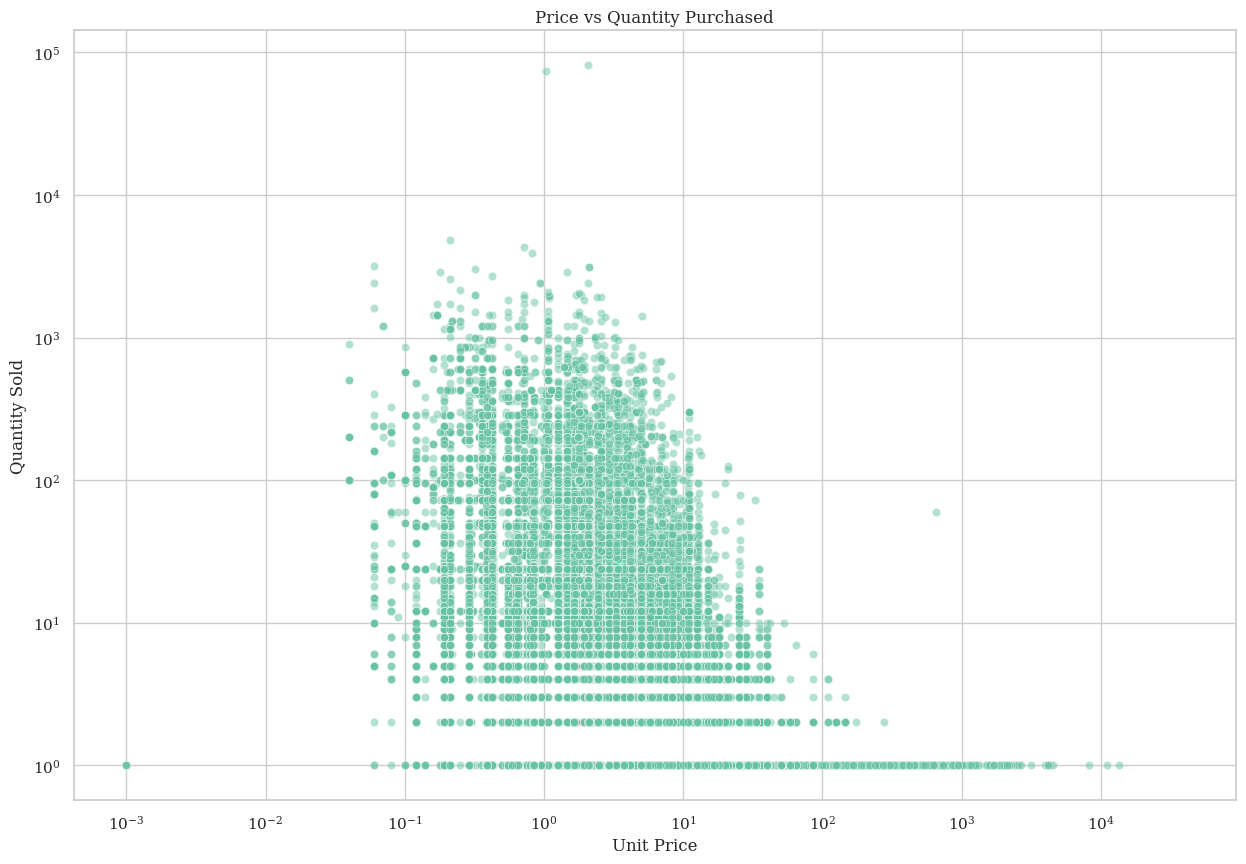

In [145]:
#lets see price and quantytit purchase for whole stock, 
plt.figure(figsize=(15,10))
sns.scatterplot(data=online_retail, x='UnitPrice', y='Quantity', alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.title("Price vs Quantity Purchased")
plt.show()

In [32]:
#let's craete a transaction summary table
transaction_summary=(online_retail.groupby(by=['InvoiceNo']).agg({'Total Amount':'sum',
                                                                      'InvoiceDate_year':'first',
                                                                      'InvoiceDate_month':'first',
                                                                      'InvoiceDate_day':'first',
                                                                      'Week':'first'})).reset_index()

transaction_summary.head()
                                                                      



,InvoiceNo,Total Amount,InvoiceDate_year,InvoiceDate_month,InvoiceDate_day,Week
0,536365,139.12,2010,12,1,Weekday
1,536366,22.20,2010,12,1,Weekday
2,536367,278.73,2010,12,1,Weekday
3,536368,70.05,2010,12,1,Weekday
4,536369,17.85,2010,12,1,Weekday


Text(0.5, 1.0, 'Disribution of Transactions Over Months')

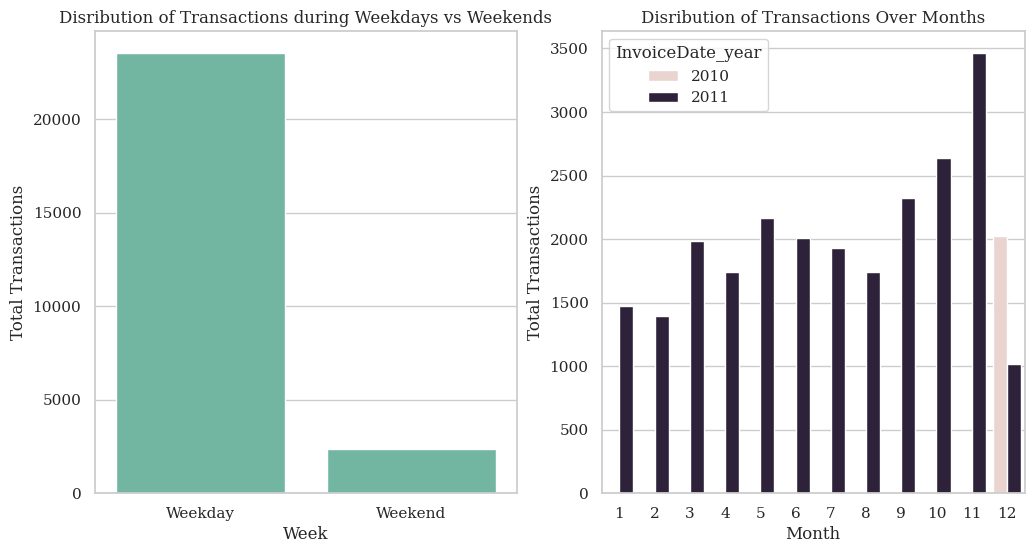

In [146]:
#from here we can check the purchase behaviours
#when is most of the shopping done by customers is it the weekend or weekday
#which month of the year most of the shopping was done

fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.countplot(data=transaction_summary,x='Week',ax=axes[0])
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Total Transactions")
axes[0].set_title("Disribution of Transactions during Weekdays vs Weekends")

sns.countplot(data=transaction_summary,x='InvoiceDate_month',ax=axes[1],hue='InvoiceDate_year')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Transactions")
axes[1].set_title("Disribution of Transactions Over Months")

 ### RFM Aanalysis



In [36]:
#for rfm analysis since we have data till 2011, lets take a reference date 2012
reference_date=pd.to_datetime('01/01/2012')

In [42]:
#we need the below columns for our rfm analysis
#customer id
#invoice number
#invoice dates
#total amount spent

rfm=(online_retail.groupby(by=['CustomerID']).agg({'InvoiceDate': lambda x: (reference_date - x.max()).days,
                                                 'InvoiceNo':'count',
                                                 'Total Amount': 'sum'})).reset_index()

#rename the columns
rfm.rename(columns={'InvoiceDate':'Recency',
                    "InvoiceNo":"Frequency",
                    'Total Amount':"Monetary"},inplace=True)


rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,347,2,0.00
1,12347.0,24,182,4310.00
2,12348.0,97,31,1797.24
3,12349.0,40,73,1757.55
4,12350.0,332,17,334.40


In [49]:
#scoring each for R,F,M
#the idea here is to score the customers based on their RFM, we will score them on the scale 1-5 1 being the lowest
#fthe dea is to split each col of r,f,m in to buckets so that accordingly score can be assigned to customer

#once rfm is calculated individualy, we will give them a customer score and a category based on score
#another score will be again rfm but this time it will be based on how frequent do they shop, how much they spend etc
#so idea is to do segmentation in two ways



rfm['Recency Score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['Frequency Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['Monetory Score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])


#since these new features are categorical, let's make tthem int
rfm['Recency Score']=rfm['Recency Score'].astype('int64')
rfm['Frequency Score']=rfm['Frequency Score'].astype('int64')
rfm['Monetory Score']=rfm['Monetory Score'].astype('int64')

#give customer score
rfm["Customer Score"]=(rfm['Recency Score'].astype('float64')+rfm['Frequency Score'].astype('float64')+rfm['Monetory Score'].astype('float64'))/3

#give another score
rfm['RFM Score']=rfm['Recency Score'].astype('str')+rfm['Frequency Score'].astype('str')+rfm['Monetory Score'].astype('str')


def assign_customer_category(customer_score):
    if customer_score>=4:
        return 'Elite Customer'
    elif 4>customer_score>=3:
        return 'Power Customer'
    elif 3>customer_score>=2:
        return 'Regular Customer'
    elif 2>customer_score>=1:
        return 'Ghost Customer'
    else:
        return 'Low Value Customer'


def assign_rfm_category(rfm_score):
    if rfm_score in ['555','455','545','554']:
        return 'VIP Shopper'
    elif rfm_score[0]=='5':
        return 'Everyday Shoppers'
    elif rfm_score[1]=='5':
        return 'Frequent Shoppers'
    elif rfm_score[2]=='5':
        return 'High Spending Shoppers'
    elif rfm_score in ['111', '112', '121', '122']:
        return 'Ghost Shoppers'
    else:
        return 'Normal Shoppers'


rfm['Customer Category']=rfm['Customer Score'].apply(lambda x: assign_customer_category(x))
rfm['RFM Category']=rfm['RFM Score'].apply(lambda x: assign_rfm_category(x))





In [51]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetory Score,Customer Score,RFM Score,Customer Category,RFM Category
0,12346.0,347,2,0.00,1,2,1,1.333333,121,Ghost Customer,Ghost Shoppers
1,12347.0,24,182,4310.00,5,5,5,5.000000,555,Elite Customer,VIP Shopper
2,12348.0,97,31,1797.24,3,3,5,3.666667,335,Power Customer,High Spending Shoppers
3,12349.0,40,73,1757.55,5,4,5,4.666667,545,Elite Customer,VIP Shopper
4,12350.0,332,17,334.40,1,3,3,2.333333,133,Regular Customer,Normal Shoppers


In [55]:
customer_summary = rfm.groupby('Customer Category').agg({'CustomerID': 'count', 'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'}).reset_index()
customer_summary.rename(columns={'CustomerID': 'Customer Count'}, inplace=True)



rfm_summary=rfm.groupby('RFM Category').agg({'CustomerID': 'count', 'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'}).reset_index()
rfm_summary.rename(columns={'CustomerID': 'Customer Count'}, inplace=True)


In [56]:
customer_summary

,Customer Category,Customer Count,Recency,Frequency,Monetary
0,Elite Customer,2280,57.017105,182.427193,3580.612374
1,Ghost Customer,1797,273.213689,1.340011,-90.584341
2,Power Customer,1982,145.172048,53.342583,821.901540
3,Regular Customer,2023,168.872467,8.819575,58.192254


In [57]:
rfm_summary

,RFM Category,Customer Count,Recency,Frequency,Monetary
0,Everyday Shoppers,843,33.290629,30.081851,479.919407
1,Frequent Shoppers,620,184.545161,194.045161,2046.207744
2,Ghost Shoppers,864,334.765046,1.495370,-141.221574
3,High Spending Shoppers,254,133.240157,57.078740,2703.878307
4,Normal Shoppers,4410,168.603855,18.354422,237.446935
5,VIP Shopper,1091,37.780935,274.527039,5923.571439


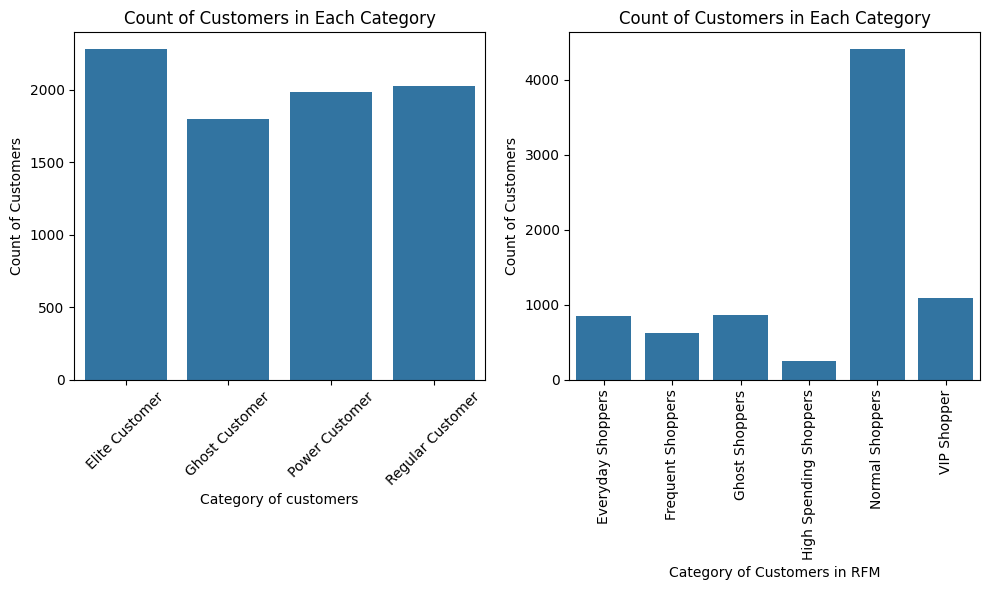

In [63]:
fig,ax=plt.subplots(1,2,figsize=(10,6))
sns.barplot(data=customer_summary,x='Customer Category',y='Customer Count',ax=ax[0])
ax[0].set_xlabel('Category of customers')
ax[0].tick_params(axis='x',rotation=45)
ax[0].set_ylabel('Count of Customers')
ax[0].set_title('Count of Customers in Each Category')


sns.barplot(data=rfm_summary,x='RFM Category',y='Customer Count',ax=ax[1])
ax[1].set_xlabel('Category of Customers in RFM')
ax[1].tick_params(axis='x',rotation=90)
ax[1].set_ylabel('Count of Customers')
ax[1].set_title('Count of Customers in Each Category')

plt.tight_layout()
plt.show()

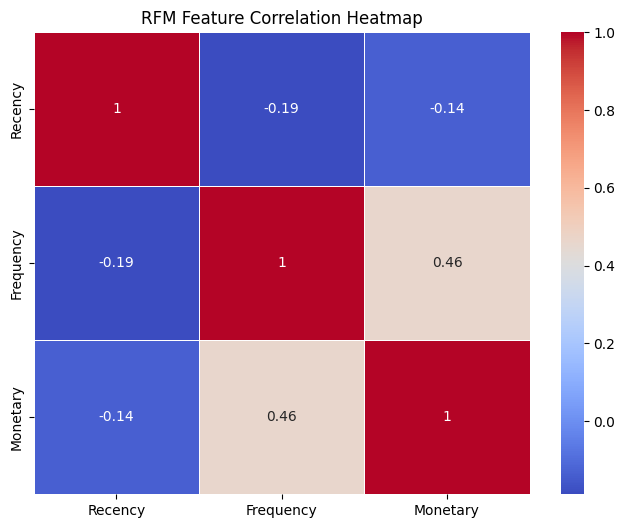

In [65]:
#let us see how recency,frequency and monetory values interact with each other, how do they correlate
plt.figure(figsize=(8, 6))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("RFM Feature Correlation Heatmap")
plt.show()

Interpretation of Correlations:
Recency & Frequency (-0.19): Weak negative correlation. This means that recent buyers tend to purchase more frequently, but the relationship isn’t that strong.
Recency & Monetary (-0.14): Very weak negative correlation. Higher spenders may not necessarily be recent buyers.
Frequency & Monetary (0.46): Moderate positive correlation. People who buy often tend to spend more. Makes sense, right? Frequent shoppers = more money spent.

What This Means for Your RFM Analysis:
Recency & Frequency aren't strongly correlated, so we need to analyze them separately.
The strongest insight comes from Frequency & Monetary (0.46), meaning targeting high-frequency customers will likely increase revenue.
This also means that just because someone spends a lot doesn’t mean they’ll keep coming back. We need retention strategies for high spenders.

/var/folders/8v/d0lxwjpj4v527f9nxwhfz6m80000gn/T/ipykernel_27388/3779855714.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=rfm, x='Recency', y='Frequency',palette='tab10', s=100)


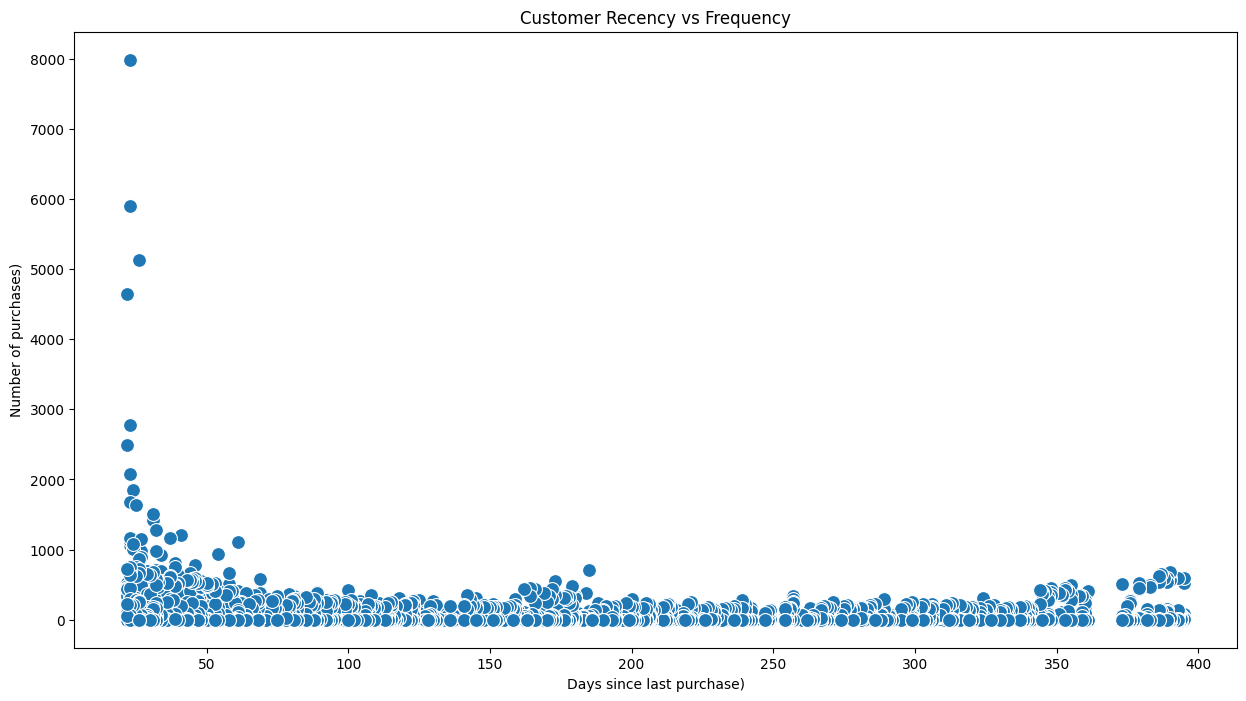

In [68]:
#scatterplot

plt.figure(figsize=(15, 8))
sns.scatterplot(data=rfm, x='Recency', y='Frequency',palette='tab10', s=100)
plt.xlabel("Days since last purchase)")
plt.ylabel("Number of purchases)")
plt.title("Customer Recency vs Frequency")
plt.show()


### Clustering - Model Training and Testing

printing number of clusters with their best max iter values: {2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100, 10: 400, 11: 100, 12: 100, 13: 100, 14: 350}


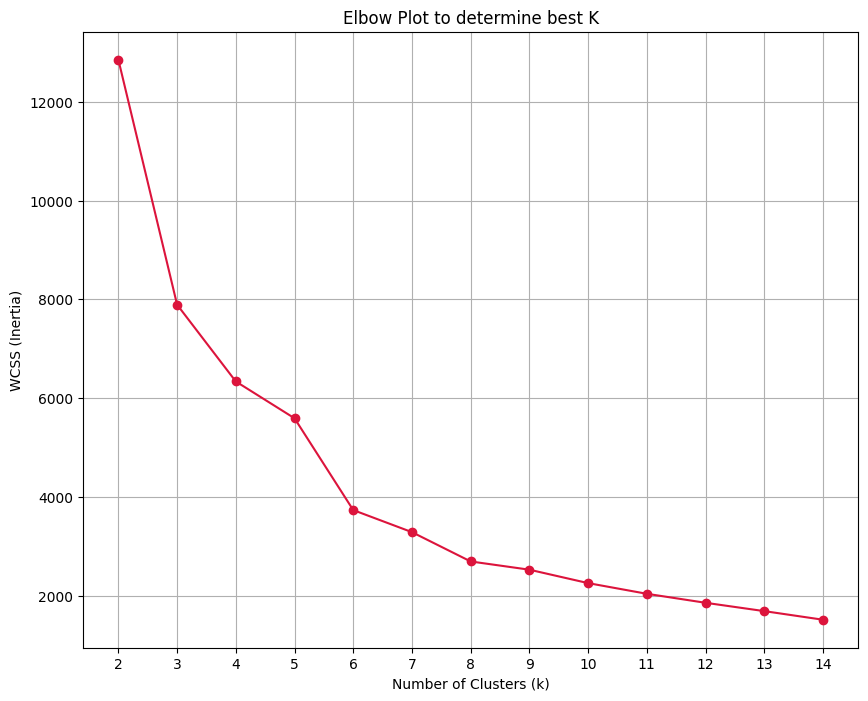

In [85]:
#recency,frequency and monetory are on different scales, so we need to sstandardize them
#first we will split the data into train and test
#we will do it using standard scalar


rfm_train,rfm_test=train_test_split(rfm,test_size=0.25,random_state=42)



scaler=StandardScaler()
rfm_train_scaled=scaler.fit_transform(rfm_train[['Recency', 'Frequency', 'Monetary']])



k_values=[i for i in range(2,15)]
iter_values=[100,150,200,250,300,350,400,450,500,550]
best_iter={}
wss=[]


for k in k_values:
    best_wss=float('inf')
    best_iter_val=None
    for iter_val in iter_values:
        kmeans=KMeans(n_clusters=k,max_iter=iter_val,random_state=42)
        kmeans.fit(rfm_train_scaled)
        curr_wss=kmeans.inertia_
        if curr_wss<best_wss:
            best_wss=curr_wss
            best_iter_val=iter_val
    wss.append(best_wss)
    best_iter[k]=best_iter_val
        
print(f"printing number of clusters with their best max iter values: {best_iter}")

#plot wssscore
plt.figure(figsize=(10,8))
plt.plot(k_values, wss, marker='o', linestyle='-', color='crimson')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Plot to determine best K")
plt.xticks(k_values)
plt.grid(True)
plt.show()
        




At k=6 we are getting an elbow, so this seems an optimal number</br>
So we run KMeans again with this optimal number of clusters


In [86]:
optimal_k=6
optimal_iter=best_iter[optimal_k]

optimal_k_means=KMeans(n_clusters=optimal_k,max_iter=optimal_iter,random_state=42)

rfm_train['KMeans_Cluster']=optimal_k_means.fit_predict(rfm_train_scaled)

In [147]:
rfm_train.head()

,CustomerID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetory Score,Customer Score,RFM Score,Customer Category,RFM Category,KMeans_Cluster
3078,16506.0,41,3,90.30,5,2,2,3.000000,522,Power Customer,Everyday Shoppers,2
434,12895.0,64,24,347.30,4,3,3,3.333333,433,Power Customer,Normal Shoppers,2
3985,17754.0,22,93,1739.92,5,4,5,4.666667,545,Elite Customer,VIP Shopper,2
751,13332.0,36,21,350.90,5,3,3,3.666667,533,Power Customer,Everyday Shoppers,2
3429,16986.0,51,3,1873.20,4,2,5,3.666667,425,Power Customer,High Spending Shoppers,2


In [93]:
#testing out model
rfm_test_scaled=scaler.transform(rfm_test[['Recency', 'Frequency', 'Monetary']])

rfm_test['KMeans_Clusters']=optimal_k_means.predict(rfm_test_scaled)


In [148]:
rfm_test.head()

,CustomerID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetory Score,Customer Score,RFM Score,Customer Category,RFM Category,KMeans_Clusters
7588,Cust576407,46,1,0.00,4,2,1,2.333333,421,Regular Customer,Normal Shoppers,2
2069,15147.0,240,29,608.65,2,3,4,3.000000,234,Power Customer,Normal Shoppers,0
7622,Cust576762,45,1,0.00,4,2,1,2.333333,421,Regular Customer,Normal Shoppers,2
2063,15140.0,74,81,2350.00,4,4,5,4.333333,445,Elite Customer,High Spending Shoppers,2
8027,CustC566168,113,1,-116.69,3,2,1,2.000000,321,Regular Customer,Normal Shoppers,2


In [101]:
#visualize the distribution in both test sets

#get both value counts after and normalize
kmeans_trainset_clusters=rfm_train['KMeans_Cluster'].value_counts(normalize=True).sort_index()
kmeans_testset_clusters=rfm_test['KMeans_Clusters'].value_counts(normalize=True).sort_index()

k_clusters_df=pd.DataFrame({"Train":kmeans_trainset_clusters,"Test":kmeans_testset_clusters}).reset_index()
k_clusters_df.rename(columns={'index': 'Cluster'}, inplace=True)




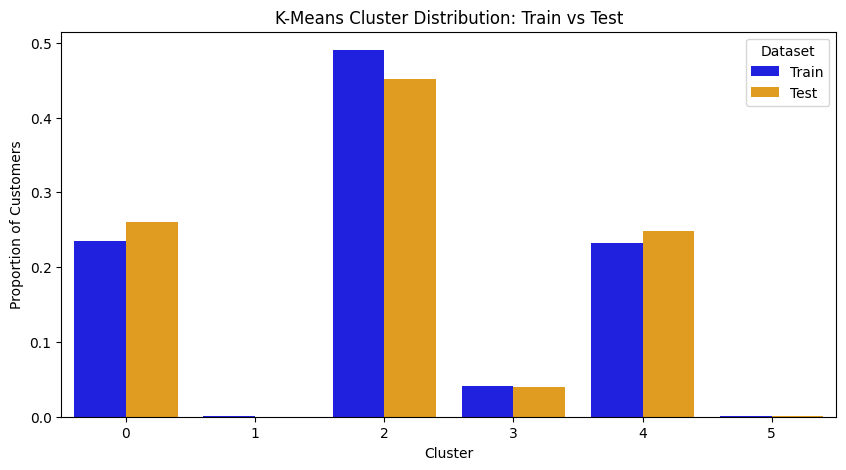

In [104]:
plt.figure(figsize=(10, 5))
sns.barplot(data=k_clusters_df.melt(id_vars=['Cluster'], var_name='Dataset', value_name='Proportion'),
            x='Cluster', y='Proportion', hue='Dataset', palette=['blue', 'orange'])
plt.xlabel("Cluster")
plt.ylabel("Proportion of Customers")
plt.title("K-Means Cluster Distribution: Train vs Test")
plt.legend(title="Dataset")
plt.show()

It seems that our model is generalizing well and also seems that few clusters doe not have any members

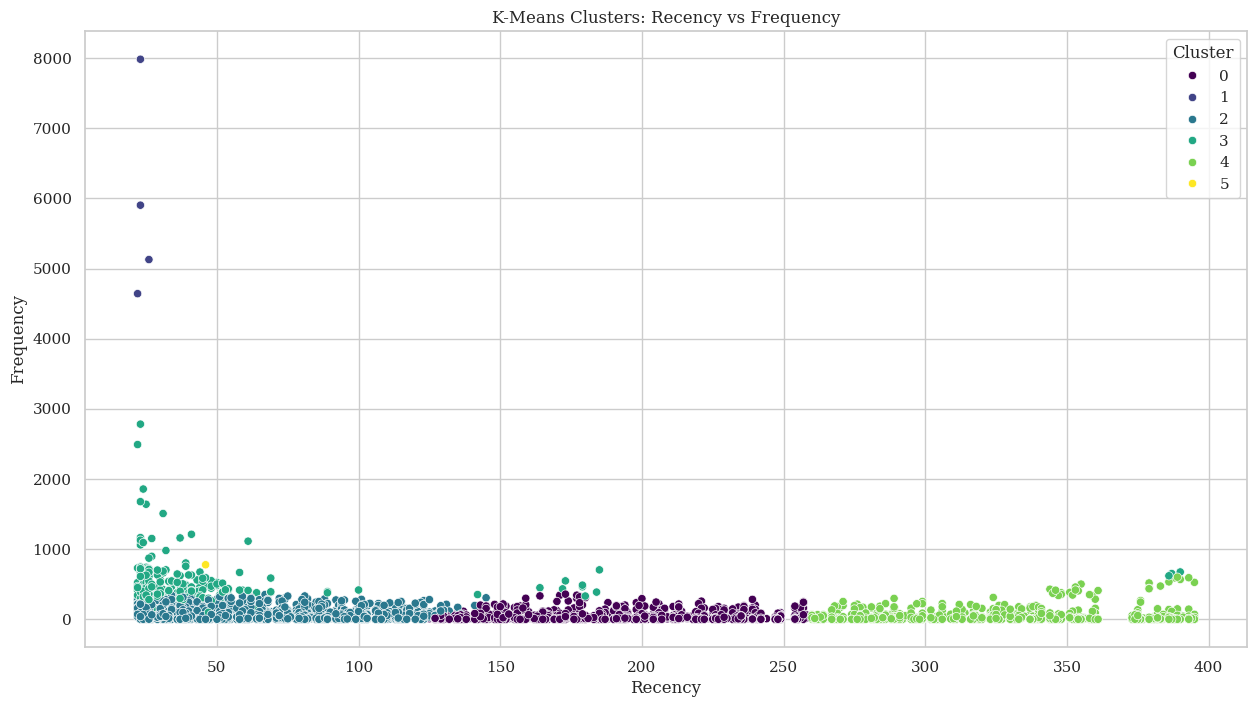

In [151]:
#plot the clusters
plt.figure(figsize=(15, 8))
sns.scatterplot(x=rfm_train['Recency'], y=rfm_train['Frequency'], hue=rfm_train['KMeans_Cluster'], palette='viridis')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('K-Means Clusters: Recency vs Frequency')
plt.legend(title="Cluster")
plt.show()


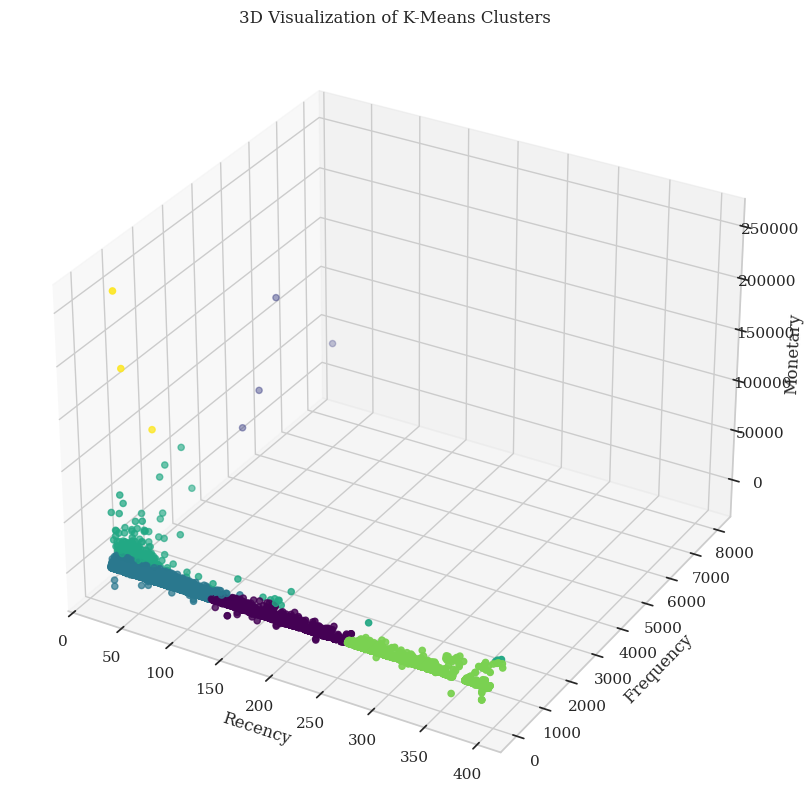

In [153]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rfm_train['Recency'], rfm_train['Frequency'], rfm_train['Monetary'], 
           c=rfm_train['KMeans_Cluster'], cmap='viridis', marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D Visualization of K-Means Clusters')
plt.show()


In [107]:
pd.crosstab(rfm_train['KMeans_Cluster'],rfm_train['RFM Category'])

RFM Category,Everyday Shoppers,Frequent Shoppers,Ghost Shoppers,High Spending Shoppers,Normal Shoppers,VIP Shopper
KMeans_Cluster,,,,,,
0,0,124,0,49,1252,0
1,0,0,0,0,0,4
2,637,204,0,133,1401,596
3,0,17,0,0,0,230
4,0,107,647,23,634,0
5,0,0,0,0,0,3


In [154]:
rfm_train[rfm_train['KMeans_Cluster']==2]

,CustomerID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetory Score,Customer Score,RFM Score,Customer Category,RFM Category,KMeans_Cluster
3078,16506.0,41,3,90.30,5,2,2,3.000000,522,Power Customer,Everyday Shoppers,2
434,12895.0,64,24,347.30,4,3,3,3.333333,433,Power Customer,Normal Shoppers,2
3985,17754.0,22,93,1739.92,5,4,5,4.666667,545,Elite Customer,VIP Shopper,2
751,13332.0,36,21,350.90,5,3,3,3.666667,533,Power Customer,Everyday Shoppers,2
3429,16986.0,51,3,1873.20,4,2,5,3.666667,425,Power Customer,High Spending Shoppers,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3444,17007.0,72,53,877.43,4,4,4,4.000000,444,Elite Customer,Normal Shoppers,2
3092,16527.0,103,14,228.06,3,3,3,3.000000,333,Power Customer,Normal Shoppers,2
3772,17466.0,32,41,763.28,5,4,4,4.333333,544,Elite Customer,Everyday Shoppers,2
7603,Cust576566,46,1,0.00,4,2,1,2.333333,421,Regular Customer,Normal Shoppers,2


### DBSCAN 

In [156]:
eps_values = [0.2, 0.5, 0.8, 1.2]  #For grid search
min_samples_values = [5, 10, 20]  #For grid search

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(rfm_train_scaled)
        print(f"EPS: {eps}, Min Samples: {min_samples}, Unique Clusters: {set(clusters)}")


EPS: 0.2, Min Samples: 5, Unique Clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -1}
EPS: 0.2, Min Samples: 10, Unique Clusters: {0, 1, 2, -1}
EPS: 0.2, Min Samples: 20, Unique Clusters: {0, 1, 2, 3, 4, -1}
EPS: 0.5, Min Samples: 5, Unique Clusters: {0, 1, -1}
EPS: 0.5, Min Samples: 10, Unique Clusters: {0, -1}
EPS: 0.5, Min Samples: 20, Unique Clusters: {0, 1, -1}
EPS: 0.8, Min Samples: 5, Unique Clusters: {0, 1, 2, -1}
EPS: 0.8, Min Samples: 10, Unique Clusters: {0, -1}
EPS: 0.8, Min Samples: 20, Unique Clusters: {0, -1}
EPS: 1.2, Min Samples: 5, Unique Clusters: {0, 1, -1}
EPS: 1.2, Min Samples: 10, Unique Clusters: {0, -1}
EPS: 1.2, Min Samples: 20, Unique Clusters: {0, -1}


In [157]:
best_eps = 0.3 
best_min_samples = 5  

#Apply DBSCAN to train dataset
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
rfm_train['DBSCAN_Cluster'] = dbscan_best.fit_predict(rfm_train_scaled)

#unique clusters formed
print(f"Unique clusters found: {set(rfm_train['DBSCAN_Cluster'])}")

#apply to test set to test the model
rfm_test_scaled = scaler.transform(rfm_test[['Recency', 'Frequency', 'Monetary']])
rfm_test['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_test_scaled)

Unique clusters found: {0, 1, 2, 3, -1}


In [162]:
#just like in k means visualize the distribution to ensure model generalizes
dbscan_trainset_clusters=rfm_train['KMeans_Cluster'].value_counts(normalize=True).sort_index()
dbscan_testset_clusters=rfm_test['KMeans_Clusters'].value_counts(normalize=True).sort_index()

dbscan_df=pd.DataFrame({"Train":dbscan_trainset_clusters,"Test":dbscan_testset_clusters}).reset_index()
k_clusters_df.rename(columns={'index': 'Cluster'}, inplace=True)


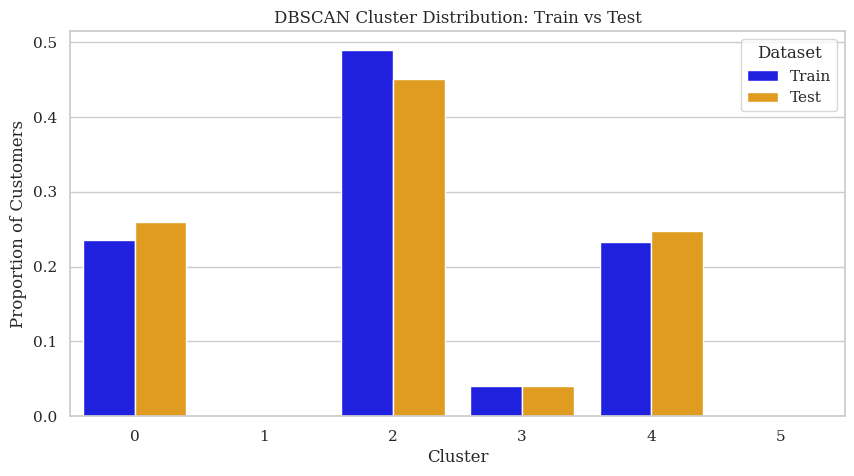

In [164]:
plt.figure(figsize=(10, 5))
sns.barplot(data=k_clusters_df.melt(id_vars=['Cluster'], var_name='Dataset', value_name='Proportion'),
            x='Cluster', y='Proportion', hue='Dataset', palette=['blue', 'orange'])
plt.xlabel("Cluster")
plt.ylabel("Proportion of Customers")
plt.title("DBSCAN Cluster Distribution: Train vs Test")
plt.legend(title="Dataset")
plt.show()

In [165]:
rfm_train.head()

,CustomerID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetory Score,Customer Score,RFM Score,Customer Category,RFM Category,KMeans_Cluster,DBSCAN_Cluster
3078,16506.0,41,3,90.30,5,2,2,3.000000,522,Power Customer,Everyday Shoppers,2,0
434,12895.0,64,24,347.30,4,3,3,3.333333,433,Power Customer,Normal Shoppers,2,0
3985,17754.0,22,93,1739.92,5,4,5,4.666667,545,Elite Customer,VIP Shopper,2,0
751,13332.0,36,21,350.90,5,3,3,3.666667,533,Power Customer,Everyday Shoppers,2,0
3429,16986.0,51,3,1873.20,4,2,5,3.666667,425,Power Customer,High Spending Shoppers,2,0


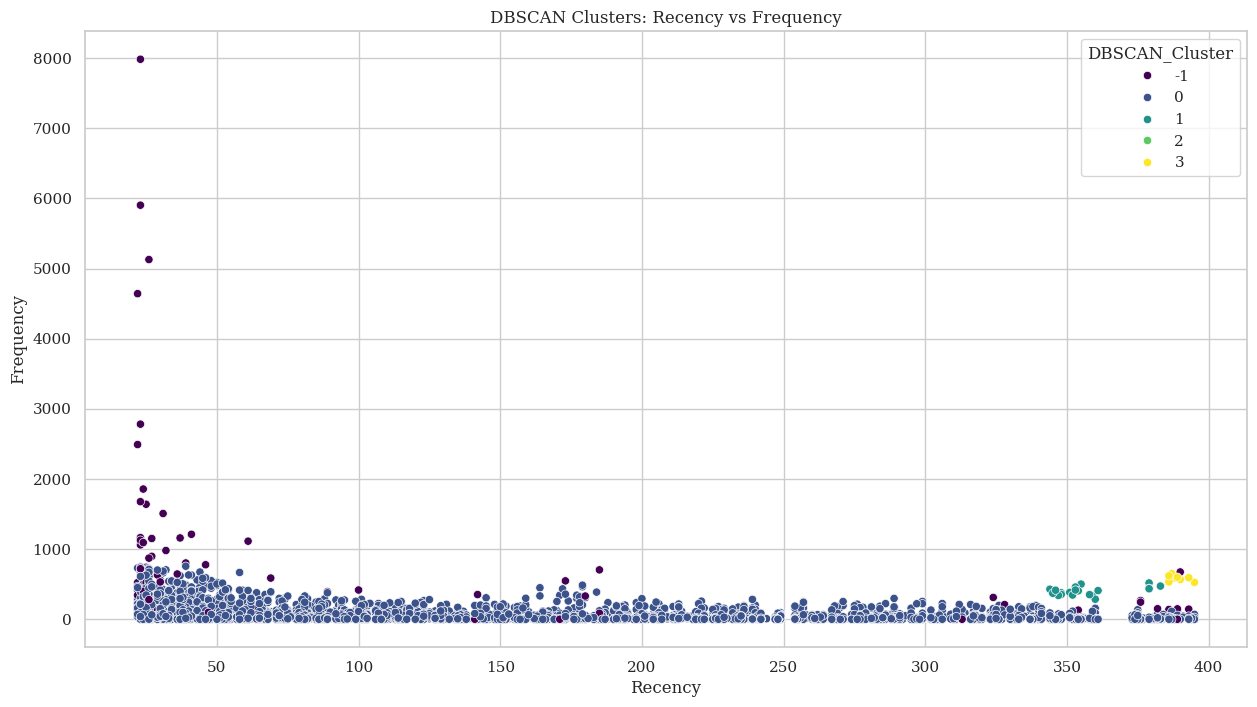

In [159]:
#visualize the clusters

plt.figure(figsize=(15,8))
sns.scatterplot(data=rfm_train, x='Recency', y='Frequency', hue='DBSCAN_Cluster', palette='viridis')
plt.title("DBSCAN Clusters: Recency vs Frequency")
plt.show()